In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitalg.tests.test3 import Test
from bitalg.visualizer.main import Visualizer

# Triangulacja wielokątów monotonicznych - problem monitorowania galerii


## Przydatne funkcje


In [3]:
polygon_example_1 = [(5,5), (3,4), (6,3), (4,2), (6,0), (7,1), (8,4)]
polygon_example_2 = [(2,0), (5,1), (6,0), (8,3), (7,2), (8,7), (6,9), (5,8), (2,9), (1,7), (2,4), (4,5), (3,6), (5, 7), (5.5, 3), (2,2), (1,3), (0,1)]
polygon_example_colors = [1, 3, 1, 0, 2, 4, 0, 2, 0, 4, 1, 4, 4, 3, 4, 2, 0, 4]
polygon_example_tri = [(polygon_example_1[0], polygon_example_1[2]),
                      (polygon_example_1[2], polygon_example_1[5]),
                      (polygon_example_1[2], polygon_example_1[6]),
                      (polygon_example_1[2], polygon_example_1[4])]

In [4]:
def draw_polygon(polygon):
    vis = Visualizer()
    points = polygon
    vis.add_polygon(polygon, fill=False)
    vis.show()

In [5]:
def draw_polygon_colors(polygon,colors):
    points_start=[]
    points_end=[]
    points_connect=[]
    points_divide=[]
    points_regular=[]
    for i in range(len(polygon)):
        if colors[i]==0:
            points_start.append(polygon[i])
        elif colors[i]==1:
            points_end.append(polygon[i])
        elif colors[i]==2:
            points_connect.append(polygon[i])
        elif colors[i]==3:
            points_divide.append(polygon[i])
        elif colors[i]==4:
            points_regular.append(polygon[i])

    vis = Visualizer()
    colors_start = ['green']
    color_end=['red']
    color_connect=['blue']
    color_divide=['cyan']
    color_regular=['#3B240B']
    vis.add_polygon(polygon, fill=False)
    vis.add_point(points_start, color=colors_start)
    vis.add_point(points_end, color=color_end)
    vis.add_point(points_connect, color=color_connect)
    vis.add_point(points_divide, color=color_divide)
    vis.add_point(points_regular, color=color_regular)
    vis.show()

In [6]:
def draw_polygon_tri(polygon,tri):

    vis = Visualizer()
    points = polygon
    tri_line_segments = tri
    vis.add_polygon(points, fill=False)
    vis.add_point(points)
    vis.add_line_segment(tri_line_segments, color='red')
    vis.show()

## Wprowadzenie
Celem ćwiczenia jest:
- sprawdzanie $y$-monotoniczności
- podział wierchołków na kategorie
- triangulacja wielokąta monotonicznego

### Przykładowy wielokąt $y$-monotoniczny

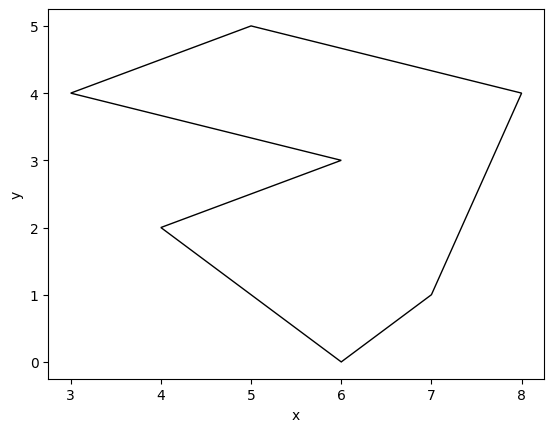

In [57]:
draw_polygon(polygon_example_1)

Do tego celu wygeneruj wielokąt.

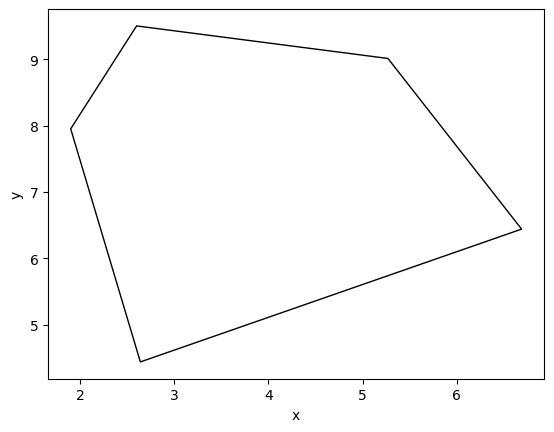

In [58]:
polygon = [(np.float64(1.9), np.float64(7.95)), (np.float64(2.64), np.float64(4.44)), (np.float64(6.69), np.float64(6.44)), (np.float64(5.27), np.float64(9.01)), (np.float64(2.6), np.float64(9.5))]
draw_polygon(polygon)


## Czy wielokąt jest $y$-monotoniczny?

Wielokąt jest monotoniczny, gdy jego wierzchołki mogą być ułożone w taki sposób, że jedna z jego współrzędnych (na przykład współrzędna $x$ lub $y$, w zależności od układu współrzędnych) zawsze rośnie lub maleje wzdłuż kolejnych wierzchołków. Innymi słowy, dla każdej pary wierzchołków wielokąta (oprócz wierzchołka startowego i końcowego), jeden z punktów ma większą (lub mniejszą) wartość danej współrzędnej niż drugi punkt.

W praktyce, wielokąt monotoniczny może być łatwiej sortowany lub przetwarzany w pewnych algorytmach geometrycznych, ponieważ istnieje pewna kolejność, w jakiej wierzchołki pojawiają się wzdłuż danej osi (np. osi $x$ lub $y$). Monotoniczność może ułatwić znajdowanie przecięć linii w takim wielokącie lub wykonywanie innych operacji geometrycznych. W tym zadaniu interesuje nas monotoniczność wielokąta wzdłuż osi $y$.

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```is_y_monotonic```. Pamiętaj, aby sprawozdanie zawierało krótki opis działania tej funkcji.

In [ ]:
def is_y_monotonic(polygon,epsilon=1e-24):
    """
    Funkcja określa czy podana figura jest y-monotoniczna.
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: wartość bool - true, jeśli wielokąt jest monotoniczny i false jeśli nie jest
    """
    n = len(polygon)
    if n <= 3:
        return True  # Trójkąt lub odcinek zawsze jest monotoniczny

    def cross_product(a, b, c):
        return (b[0] - a[0]) * (c[1] - b[1]) - (b[1] - a[1]) * (c[0] - b[0])

    for i in range(n):
        curr_p = polygon[i]
        prev_p = polygon[i - 1]          
        next_p = polygon[(i + 1) % n]   

        cp = cross_product(prev_p, curr_p, next_p)

        is_merge = (prev_p[1] > curr_p[1] and next_p[1] > curr_p[1]) and (cp < epsilon)

        if is_merge:
            return False
        
        is_split = (prev_p[1] < curr_p[1] and next_p[1] < curr_p[1]) and (cp < epsilon)

        if is_split:
            return False

    # Jeśli wielokąt nie ma wierzchołków dzielących ani łączących, jest y-monotoniczny 
    return True

Przeprowadź test poprawności powyższej funkcji.

In [10]:
Test().runtest(1, is_y_monotonic)

Lab 3, task 1:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
Result: 10/10
Time: 0.006s


Sprawdź monotoniczność swojego wielokątu.

In [63]:
print(is_y_monotonic(polygon_example_1))

True


***

# Podział wierzchołków na kategorie

Wierzchołki naszego wielokąta możemy podzielić na parę kategorii:
- początkowe, gdy obaj jego sąsiedzi leżą poniżej i kąt wewnętrzny ma mniej niż 180 stopni. To wierzchołki, w których zaczyna się monotoniczny spadek
- końcowe, gdy obaj jego sąsiedzi leżą powyżej i kąt wewnętrzny ma mniej niż 180 stopni. To wierzchołki, w których monotoniczność wielokąta się zmienia, czyli na przykład zaczyna się monotoniczny wzrost, jeśli wcześniej był spadek, lub na odwrót.

Wierzchołki startowe i końcowe są ważne w kontekście algorytmów przetwarzania wielokątów monotonicznych, takich jak algorytmy dziel i zwyciężaj oraz triangulacji.
- dzielący, gdy obaj jego sąsiedzi leżą poniżej i kąt wewnęntrzny ma więcej niż 180 stopni. To wierzchołki, które wyznaczają przekątne (linie łączące), tworzące trójkąty podczas triangulacji.
- łączący, gdy obaj jego sąsiedzi leżą powyżej i kąt wewnęntrzny ma więcej niż 180 stopni. To wierzchołki, które są połączone liniami (przekątnymi) wewnątrz wielokąta, tworząc trójkąty.

Wierzchołki łączące i dzielące odgrywają kluczową rolę w procesie triangulacji wielokątów, pozwalając na podział figury na trójkąty w sposób bezkolizyjny.
- prawidłowy, pozostałe przypadki, jeden sąsiad powyżej, drugi poniżej


### Przykładowy wielokąt z pokolorowanymi wierzchołkami.

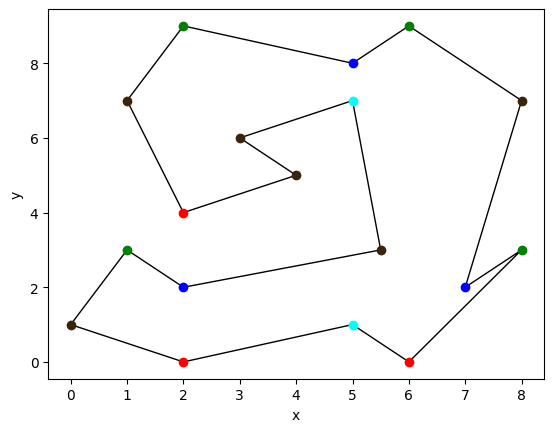

In [60]:
draw_polygon_colors(polygon_example_2,polygon_example_colors)

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```color_vertex``` .

In [ ]:
def color_vertex(polygon,epsilon=1e-24):
    """ Funkcja dzieli wierzchołki na kategorie i przypisuje wierzchołkom odpowiednie numery:
      0 - początkowy, 1 - końcowy, 2 - łączący, 3 - dzielący, 4 - prawdiłowy 
      :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt 
      :return: tablica o długości n, gdzie n = len(polygon), zawierająca cyfry z przedziału 0 - 4, gdzie T[i] odpowiada kategorii i-tego wierzchołka. """
    def cross_product(a, b, c):
        return (b[0] - a[0]) * (c[1] - b[1]) - (b[1] - a[1]) * (c[0] - b[0])

    n = len(polygon)
    result = []

    for i in range(n):
        curr_p = polygon[i]
        prev_p = polygon[i - 1]  
        next_p = polygon[(i + 1) % n]
        
        is_convex = cross_product(prev_p,curr_p,next_p) > epsilon

        neighbors_below = prev_p[1] < curr_p[1] and next_p[1] < curr_p[1]
        neighbors_above = prev_p[1] > curr_p[1] and next_p[1] > curr_p[1]

        if neighbors_below:
            if is_convex:
                result.append(0)
            else:
                result.append(3)
        
        elif neighbors_above:
            if is_convex:
                result.append(1)
            else:
                result.append(2)
        
        else:
            result.append(4)

    return result

Przeprowadź test poprawności powyższej funkcji. 

In [14]:
Test().runtest(2, color_vertex)

Lab 3, task 2:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
Result: 10/10
Time: 0.007s


Zwizualizuj swój wielokąt z pokolorowanymi według kategorii wierzchołkami.

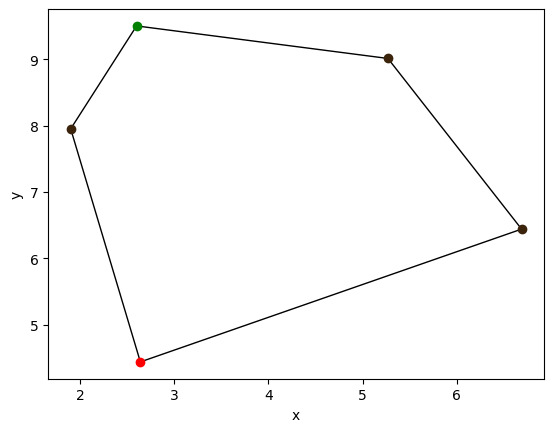

In [61]:
colors = color_vertex(polygon)
draw_polygon_colors(polygon,colors)

***

# Triangulacja wielokąta monotonicznego

Triangulacja wielokąta monotonicznego to proces podziału wielokąta monotonicznego na trójkąty poprzez dodawanie przekątnych (linii łączących wierzchołki), które nie przecinają się wewnętrznie.

### Przykładowy wielokąt podzielony na trójkąty.

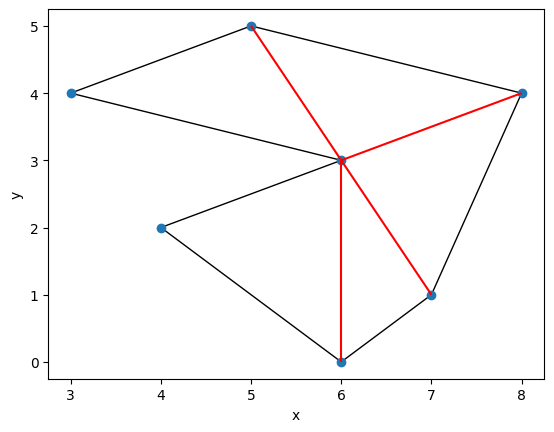

In [62]:
draw_polygon_tri(polygon_example_1, polygon_example_tri)

<span style="color:red">Ćw.</span> Uzupełnij funkcję ```triangulation```. Wykorzystaj algorytm opisany na wykładzie.

In [64]:
def triangulation(polygon,epsilon=1e-24):
    """
    Funkcja dokonuje triangulacji wielokąta monotonicznego.
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: tablica krotek dodawanych po kolei przekątnych np: [(1,5),(2,3)], oznacza, że triangulacja polega na dodaniu przekątnej pomiędzy wierzchołki o indeksach 1 i 5 oraz 2 i 3
            tablica krotek trójkątów powstałych w wyniku triangulacji np: [(0,1,2),(1,2,3)], oznacza, że triangulacja polega na utworzeniu trójkątów z wierzchołków o indeksach (0,1,2) oraz (1,2,3)
    """
    n = len(polygon)
    if n <= 3:
        return [], [tuple(sorted((0, 1, 2)))] if n == 3 else []

    def cross_product(a, b, c):
        return (b[0] - a[0]) * (c[1] - b[1]) - (b[1] - a[1]) * (c[0] - b[0])

    sorted_indices = sorted(range(n), key=lambda i: (-polygon[i][1], polygon[i][0]))
    
    top_idx = sorted_indices[0]
    bottom_idx = sorted_indices[-1]
    
    left_chain = set()
    curr = top_idx
    while curr != bottom_idx:
        left_chain.add(curr)
        curr = (curr + 1) % n
    left_chain.add(bottom_idx)

    def is_left_chain(idx):
        return idx in left_chain

    stack = [sorted_indices[0], sorted_indices[1]]
    diagonals = []
    triangles = []

    for j in range(2, n - 1):
        u = sorted_indices[j]
        stack_top = stack[-1]

        u_on_left = is_left_chain(u)
        top_on_left = is_left_chain(stack_top)

        if u_on_left != top_on_left:
            v_top = stack.pop()
            diagonals.append(tuple(sorted((u, v_top))))
            
            last_v = v_top
            
            while len(stack) > 1:
                v = stack.pop()
                diagonals.append(tuple(sorted((u, v))))
                triangles.append(tuple(sorted((u, last_v, v))))
                last_v = v
            
            if stack:
                v_bottom = stack[-1]
                triangles.append(tuple(sorted((u, last_v, v_bottom))))
                stack.pop()

            stack.append(v_top)
            stack.append(u)

        else:
            last_popped = stack.pop()
            
            while len(stack) > 0:
                curr_top = stack[-1]
                cp = cross_product(polygon[curr_top], polygon[last_popped], polygon[u])
                
                valid = False
                if u_on_left:
                    if cp > epsilon: valid = True 
                else:
                    if cp < -epsilon: valid = True 

                if valid:
                    diagonals.append(tuple(sorted((u, curr_top))))
                    triangles.append(tuple(sorted((u, last_popped, curr_top))))
                    last_popped = stack.pop()
                else:
                    break
            
            stack.append(last_popped)
            stack.append(u)

    last_vertex = sorted_indices[-1]
    
    if stack:
        prev_v = stack.pop()
        
    while len(stack) > 0:
        v = stack.pop()
        
        if len(stack) > 0:
            diagonals.append(tuple(sorted((last_vertex, v))))
            
        triangles.append(tuple(sorted((last_vertex, prev_v, v))))
        prev_v = v

    return diagonals, triangles

Jakich struktur można użyć do przechowywania wielokątu, oraz utworzonej triangulacji? Uzasadnij wybór struktury w swoim algorytmie

ODPOWIEDŹ: 

In [ ]:
def triangulation_draw(polygon,epsilon=1e-24):
    """
    Funkcja dokonuje triangulacji wielokąta monotonicznego.
    :param polygon: tablica krotek punktów na płaszczyźnie euklidesowej podanych przeciwnie do ruchu wskazówek zegara - nasz wielokąt
    :return: tablica krotek dodawanych po kolei przekątnych np: [(1,5),(2,3)], oznacza, że triangulacja polega na dodaniu przekątnej pomiędzy wierzchołki o indeksach 1 i 5 oraz 2 i 3
    """
    def cross_product(a, b, c):
        return (b[0] - a[0]) * (c[1] - b[1]) - (b[1] - a[1]) * (c[0] - b[0])

    n = len(polygon)
    if n <= 3:
        return []
    
    vis = Visualizer()
    draw_lines=[(polygon[i],polygon[i+1]) for i in range(0,len(polygon)-1)]
    draw_lines.append((polygon[0],polygon[-1]))
    vis.add_line_segment(draw_lines,color="black")

    sorted_indices = sorted(range(n), key=lambda i: (-polygon[i][1], polygon[i][0]))
    
    top_idx = sorted_indices[0]
    bottom_idx = sorted_indices[-1]
    
    left_chain = set()
    curr = top_idx
    while curr != bottom_idx:
        left_chain.add(curr)
        curr = (curr + 1) % n
    left_chain.add(bottom_idx)

    def is_left_chain(idx):
        return idx in left_chain

    stack = [sorted_indices[0], sorted_indices[1]]
    vis.add_point([polygon[stack[0]],polygon[stack[1]]],color="red")
    diagonals = []

    for j in range(2, n - 1):
        u = sorted_indices[j]
        stack_top = stack[-1]
        vis.add_point(polygon[stack_top],color="yellow")
        vis.add_point(polygon[u],color="red")

        u_on_left = is_left_chain(u)
        top_on_left = is_left_chain(stack_top)

        if u_on_left != top_on_left:
            v_top = stack.pop()
            diagonals.append(tuple(sorted((u, v_top))))
            vis.add_line_segment(tuple(sorted((polygon[u], polygon[v_top]))),color="red")
            
            while len(stack) > 1:
                v = stack.pop()
                diagonals.append(tuple(sorted((u, v))))
                vis.add_line_segment(tuple(sorted((polygon[u], polygon[v_top]))),color="red")
            
            if stack:
                stack.pop()

            stack.append(v_top)
            stack.append(u)
            

        else:
            last_popped = stack.pop()
            vis.add_point(polygon[last_popped],color="yellow")
            vis.add_point(polygon[u],color="red")
            while len(stack) > 0:
                curr_top = stack[-1]
                cp = cross_product(polygon[curr_top], polygon[last_popped], polygon[u])
                
                valid = False
                if u_on_left:
                    if cp > epsilon: valid = True
                else:
                    if cp < -epsilon: valid = True

                if valid:
                    diagonals.append(tuple((u, curr_top)))
                    vis.add_line_segment(tuple(sorted((polygon[u], polygon[curr_top]))),color="red")
                    last_popped = stack.pop()
                else:
                    break
            
            stack.append(last_popped)
            stack.append(u)
            

    last_vertex = sorted_indices[-1]
    
    if stack:
        v = stack.pop()
        vis.add_point(polygon[v],color="red")
        
    while len(stack) > 1:
        v = stack.pop()
        vis.add_point(polygon[v],color="yellow")
        diagonals.append(tuple(sorted((last_vertex, v))))
        vis.add_line_segment(tuple(sorted((polygon[last_vertex], polygon[v]))),color="red")

    return vis

Przeprowadź testy poprawności powyższej funkcji.


In [19]:
Test().runtest(3, triangulation)

Lab 3, task 3:
	Test 1: Passed
	Test 2: Passed
	Test 3: Passed
	Test 4: Passed
	Test 5: Passed
	Test 6: Passed
	Test 7: Passed
	Test 8: Passed
	Test 9: Passed
	Test 10: Passed
Result: 10/10
Time: 0.006s


Zwizualizuj powstały wielokąt podzielony na trójkąty.

In [71]:
polygon1 = [(np.float64(2.1), np.float64(2.54)), (np.float64(3.98), np.float64(1.63)), (np.float64(5.86), np.float64(1.8)), (np.float64(7.35), np.float64(2.96)), (np.float64(8.31), np.float64(4.94)), (np.float64(7.79), np.float64(7.09)), (np.float64(6.04), np.float64(8.13)), (np.float64(4.19), np.float64(8.64)), (np.float64(2.42), np.float64(7.6)), (np.float64(1.44), np.float64(5.75)), (np.float64(1.46), np.float64(3.86))]
polygon2 = [(np.float64(1.84), np.float64(3.34)), (np.float64(4.37), np.float64(1.61)), (np.float64(9.07), np.float64(1.79)), (np.float64(5.11), np.float64(4.07)), (np.float64(8.56), np.float64(5.68)), (np.float64(8.56), np.float64(7.58)), (np.float64(6.62), np.float64(8.94)), (np.float64(3.28), np.float64(8.6)), (np.float64(1.14), np.float64(6.25)), (np.float64(0.86), np.float64(4.75))]
polygon3 = [(np.float64(2.23), np.float64(1.14)), (np.float64(7.93), np.float64(0.53)), (np.float64(9.56), np.float64(5.1)), (np.float64(7.02), np.float64(9.42)), (np.float64(3.05), np.float64(9.45)), (np.float64(0.99), np.float64(8.25)), (np.float64(3.52), np.float64(7.65)), (np.float64(1.1), np.float64(6.78)), (np.float64(3.66), np.float64(5.93)), (np.float64(1.14), np.float64(4.81)), (np.float64(4.11), np.float64(3.96)), (np.float64(1.45), np.float64(2.64)), (np.float64(3.35), np.float64(2.29))]
polygon4 = [(np.float64(5.15), np.float64(1.27)), (np.float64(8.16), np.float64(2.23)), (np.float64(5.57), np.float64(3.22)), (np.float64(8.15), np.float64(4.35)), (np.float64(5.79), np.float64(5.32)), (np.float64(8.45), np.float64(6.44)), (np.float64(6.13), np.float64(7.52)), (np.float64(4.96), np.float64(8.79)), (np.float64(3.85), np.float64(7.65)), (np.float64(1.26), np.float64(7.56)), (np.float64(3.73), np.float64(5.4)), (np.float64(1.65), np.float64(4.11)), (np.float64(3.69), np.float64(3.64)), (np.float64(1.62), np.float64(1.92)), (np.float64(3.49), np.float64(1.23))]
polygon5 = [(np.float64(8.64), np.float64(1.88)), (np.float64(4.7), np.float64(8.3)), (np.float64(4.78), np.float64(7.48)), (np.float64(4.7), np.float64(6.98)), (np.float64(4.4), np.float64(6.5)), (np.float64(4.11), np.float64(6.16)), (np.float64(3.54), np.float64(5.75)), (np.float64(3.02), np.float64(5.43)), (np.float64(2.49), np.float64(5.19)), (np.float64(1.84), np.float64(5.14))]
polygon6 = [(np.float64(4.22), np.float64(1.55)), (np.float64(7.74), np.float64(1.1)), (np.float64(6.7), np.float64(2.94)), (np.float64(4.84), np.float64(3.6)), (np.float64(4.98), np.float64(4.29)), (np.float64(6.86), np.float64(4.3)), (np.float64(7.59), np.float64(3.41)), (np.float64(8.38), np.float64(3.93)), (np.float64(8.96), np.float64(4.99)), (np.float64(8.52), np.float64(6.88)), (np.float64(6.75), np.float64(7.68)), (np.float64(4.24), np.float64(7.61)), (np.float64(2.75), np.float64(5.7)), (np.float64(3.5), np.float64(4.75)), (np.float64(2.37), np.float64(4.2)), (np.float64(1.62), np.float64(6.16)), (np.float64(2.56), np.float64(7.26)), (np.float64(2.05), np.float64(7.43)), (np.float64(1.12), np.float64(7.39)), (np.float64(0.56), np.float64(4.78)), (np.float64(3.52), np.float64(1.1)), (np.float64(4.23), np.float64(1.15))]
polygon7 = [(np.float64(6.95), np.float64(5.95)), (np.float64(5.61), np.float64(8.85)), (np.float64(4.28), np.float64(6.04)), (np.float64(1.27), np.float64(6.55)), (np.float64(3.73), np.float64(4.15)), (np.float64(1.87), np.float64(1.45)), (np.float64(5.31), np.float64(3.07)), (np.float64(8.4), np.float64(1.65)), (np.float64(7.09), np.float64(4.12)), (np.float64(9.77), np.float64(5.84))] 
polygon8 = [(np.float64(3.01), np.float64(2.53)), (np.float64(6.94), np.float64(3.02)), (np.float64(4.9), np.float64(3.7)), (np.float64(7.35), np.float64(4.25)), (np.float64(5.17), np.float64(4.86)), (np.float64(7.7), np.float64(5.22)), (np.float64(5.77), np.float64(6.14)), (np.float64(8.56), np.float64(6.71)), (np.float64(4.52), np.float64(8.47))]
polygons = [polygon1,polygon8,polygon2,polygon3,polygon4,polygon5,polygon6,polygon7,]

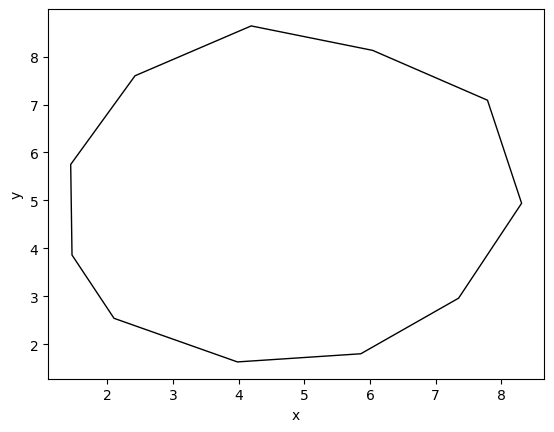

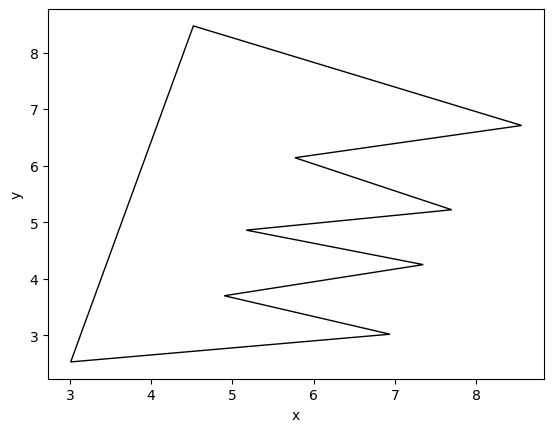

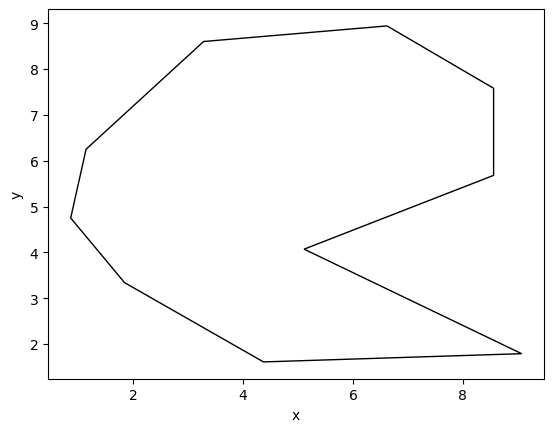

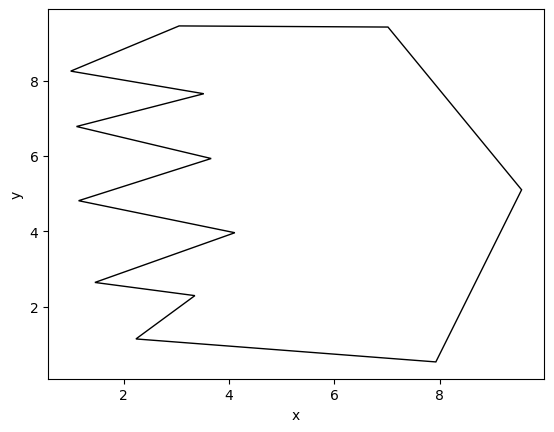

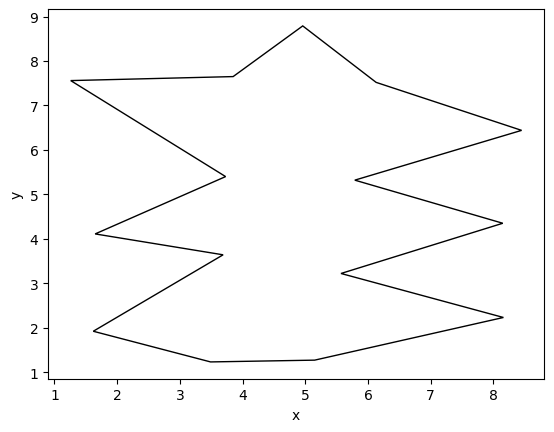

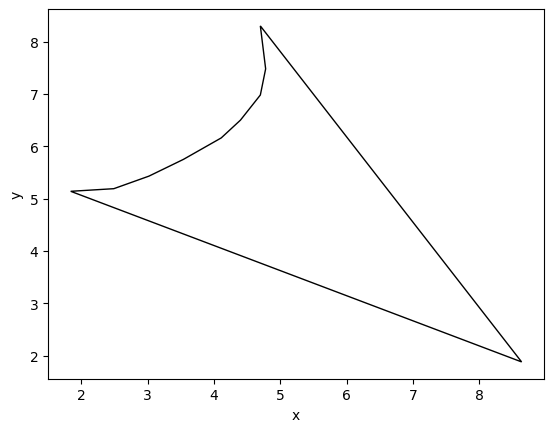

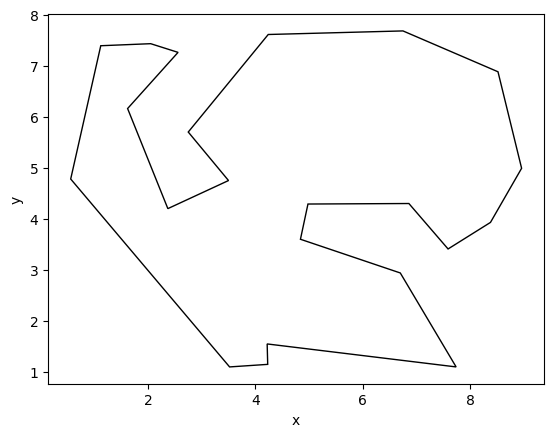

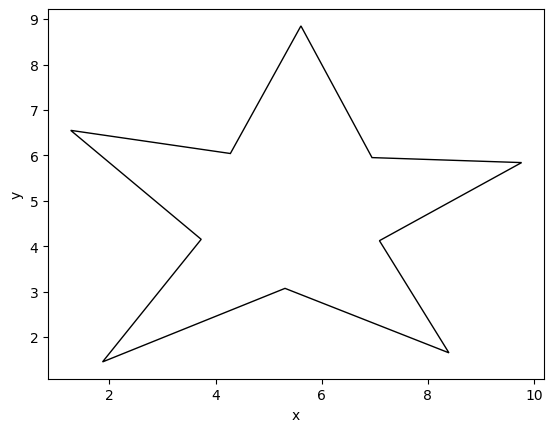

In [72]:
for pol in polygons:
    draw_polygon(pol)

In [73]:
for pol in polygons:
    print(is_y_monotonic(pol))

True
True
True
True
True
True
False
False


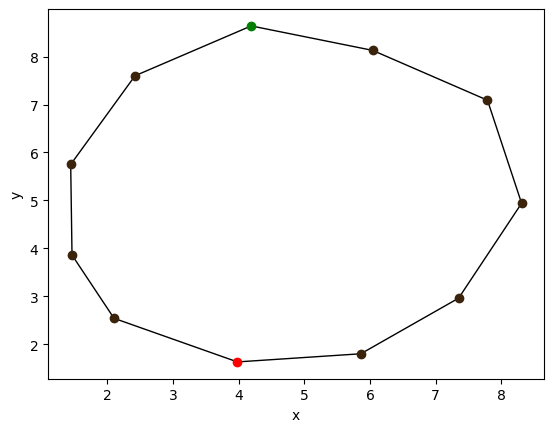

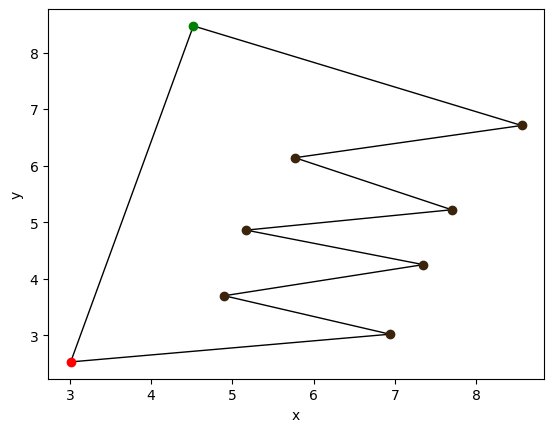

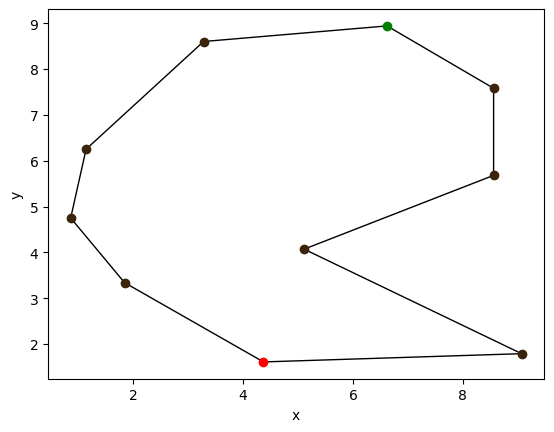

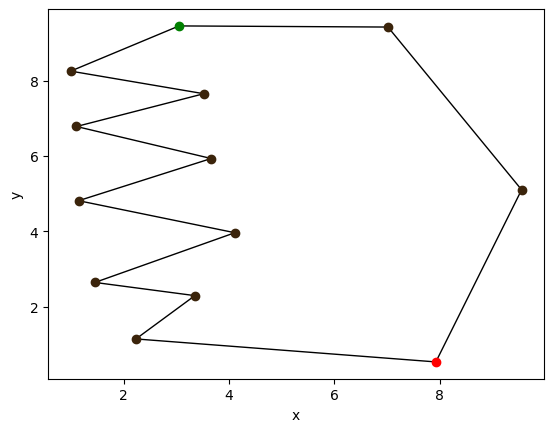

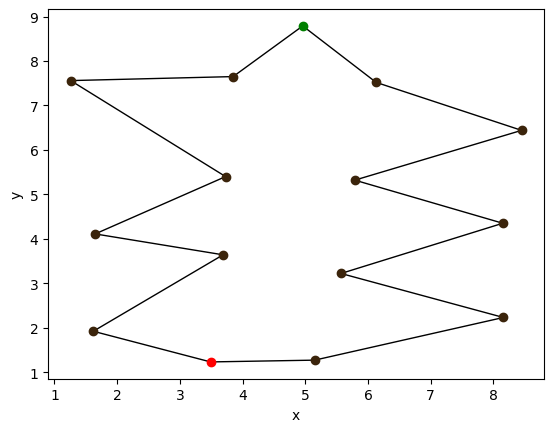

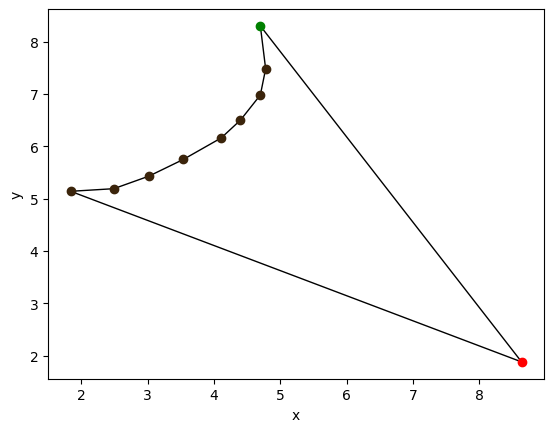

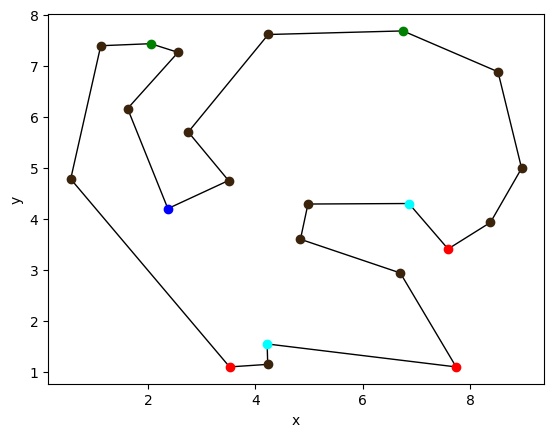

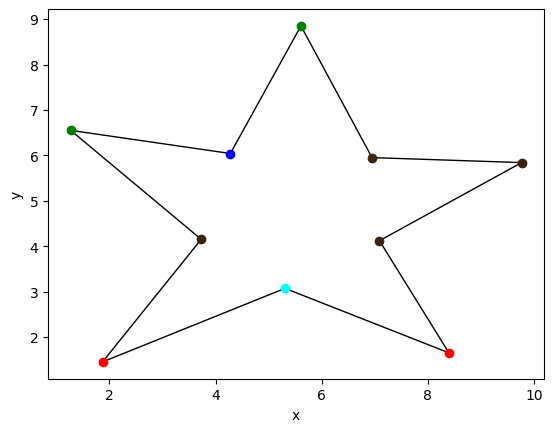

In [74]:
for pol in polygons:
    colors = color_vertex(pol)
    draw_polygon_colors(pol,colors)

11 8
9 6
10 7
13 10
15 12
10 7
22 19
10 7


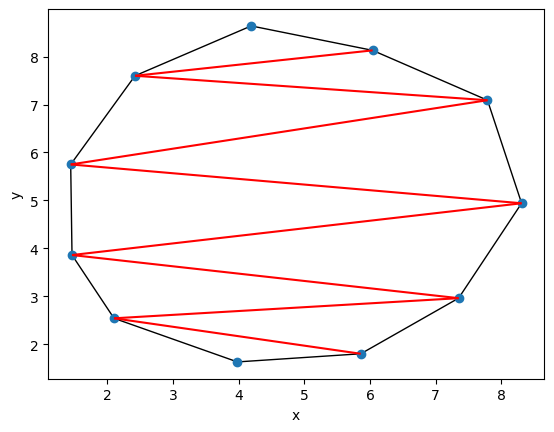

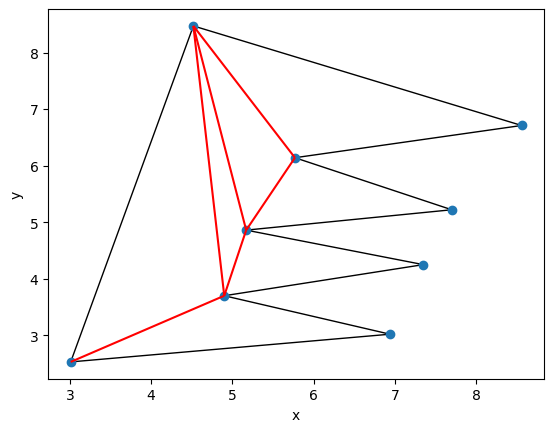

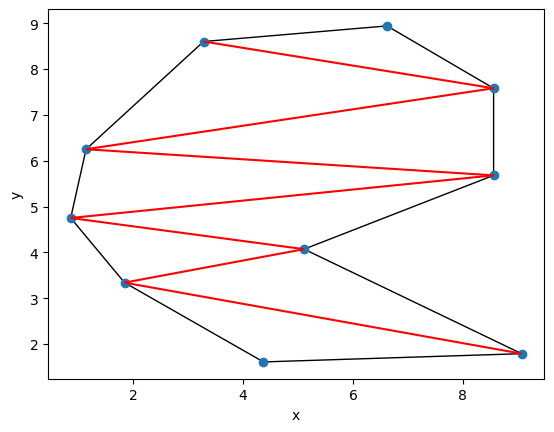

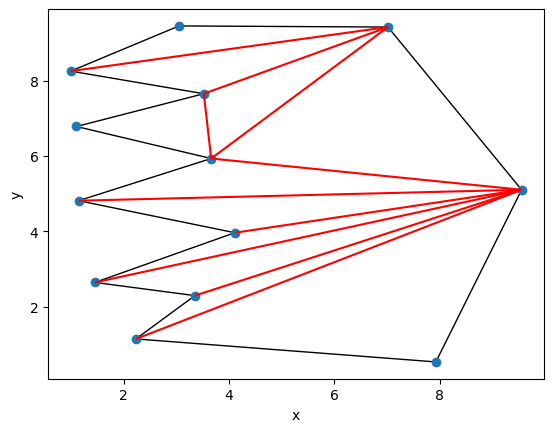

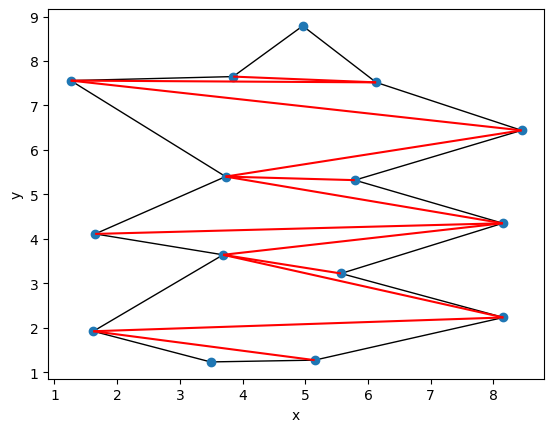

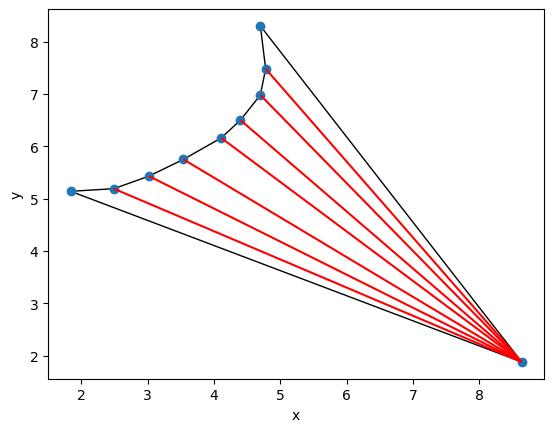

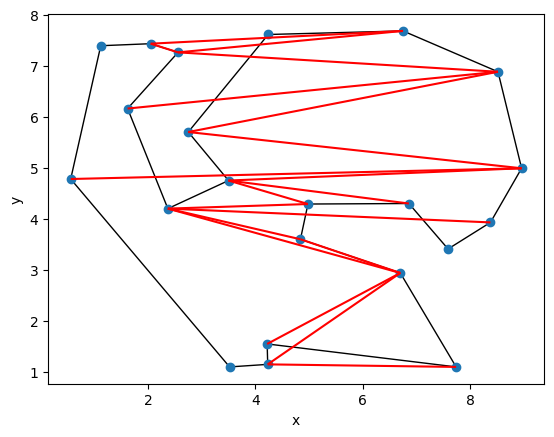

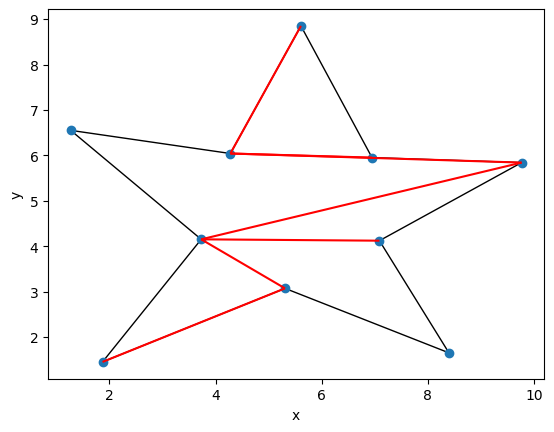

In [75]:
for pol in polygons:
    tri, _ = triangulation(pol)
    draw_polygon_tri(pol, [(pol[x], pol[y]) for (x, y) in tri])
    print(len(pol),len(tri))

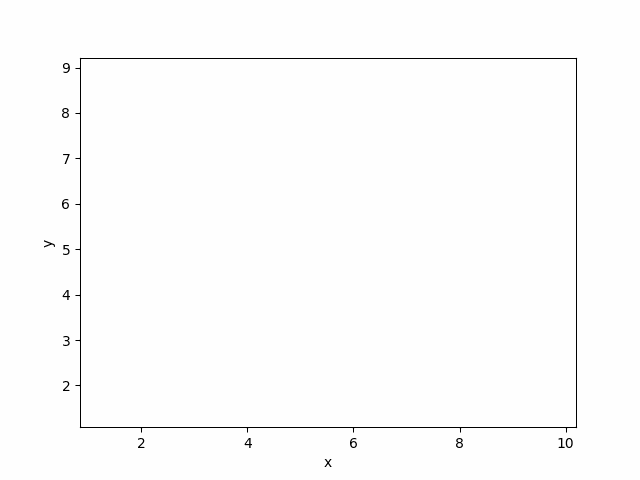

In [83]:
vis = triangulation_draw(polygons[7])
vis.show_gif(interval=300)
